In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
df=pd.read_csv('/content/drive/MyDrive/colab/placement_predict_50k_adjusted.csv')
df.head()

,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,CGPA,AttendancePercent,Internships,...,Workshops,Certifications,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,PlacementStatus,IsAnomaly
0,Female,Delhi,Tier3,IT,DataScience,Yes,Yes,6.63,68.3,2,...,0.0,1,0,62.3,6.57,40.6,65.7,No,0,0
1,Male,Chennai,Tier2,ECE,AI,Yes,No,6.40,71.0,1,...,0.0,2,0,44.0,5.86,40.3,51.8,No,0,0
2,Female,Hyderabad,Tier3,ECE,Networking,No,No,7.73,75.1,1,...,2.0,2,1,73.8,7.50,73.6,67.9,No,1,0
3,Female,Jaipur,Tier3,ECE,Embedded,No,No,9.73,99.2,4,...,5.0,6,2,100.0,9.41,98.7,NaN,No,1,0
4,Male,Ahmedabad,Tier3,Mechanical,DataScience,No,No,9.01,99.6,2,...,NaN,4,2,90.8,9.24,83.1,100.0,No,1,0


Iteration 0: Loss=0.2377
Iteration 100: Loss=0.0896
Iteration 200: Loss=0.0765
Iteration 300: Loss=0.0747
Iteration 400: Loss=0.0745
Iteration 500: Loss=0.0744
Iteration 600: Loss=0.0744
Iteration 700: Loss=0.0744
Iteration 800: Loss=0.0744
Iteration 900: Loss=0.0744
MSE: 0.1476804216205565
R2 Score: 0.4076016841082043


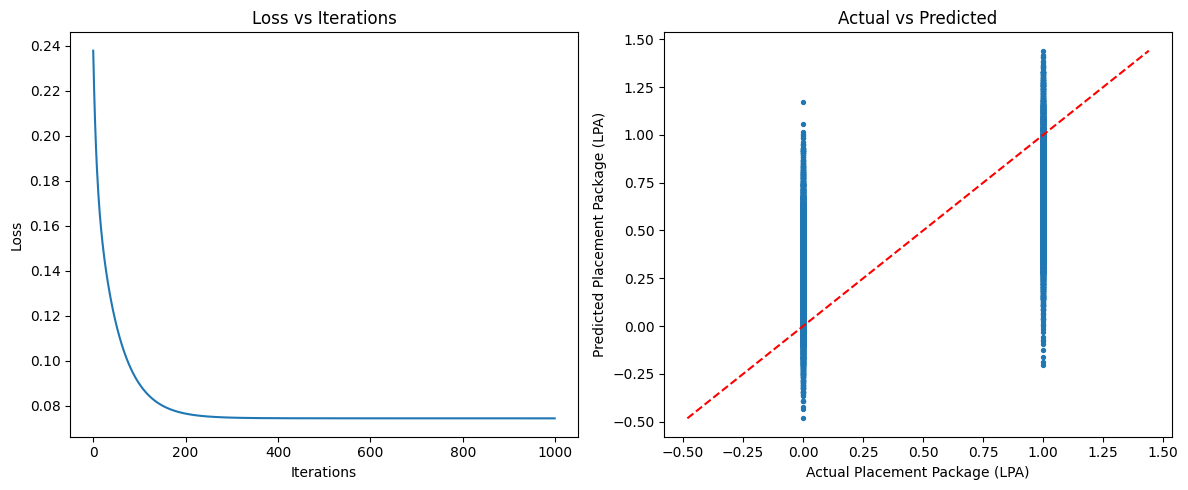

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
df = pd.read_csv('/content/drive/MyDrive/colab/placement_predict_50k_adjusted.csv')

# Predict Placement Package instead of CGPA
TARGET='PlacementStatus'

remove=['StudentID','CGPA','CGPA_Tier']+[f'SGPA_Sem{i}' for i in range(1,9)]
remove=[c for c in remove if c in df.columns and c!=TARGET]
X=df.drop(columns=remove+[TARGET]).select_dtypes(include=[np.number]).fillna(df.median(numeric_only=True)).values
y=df[TARGET].values.reshape(-1,1)

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)
X_train=np.c_[np.ones((X_train.shape[0],1)),X_train]
X_test=np.c_[np.ones((X_test.shape[0],1)),X_test]

def gradient_descent(X,y,lr=0.01,epochs=1000):
    m,n=X.shape
    theta=np.zeros((n,1))
    losses=[]
    for i in range(epochs):
        pred=X@theta
        err=pred-y
        loss=(1/(2*m))*np.sum(err**2)
        grad=(1/m)*(X.T@err)
        theta-=lr*grad
        losses.append(loss)
        if i%100==0:
            print(f'Iteration {i}: Loss={loss:.4f}')
    return theta,losses

theta,losses=gradient_descent(X_train,y_train)
pred=X_test@theta
print('MSE:',mean_squared_error(y_test,pred))
print('R2 Score:',r2_score(y_test,pred))

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(losses)
plt.title('Loss vs Iterations')
plt.xlabel('Iterations')
plt.ylabel('Loss')

plt.subplot(1,2,2)
plt.scatter(y_test,pred,s=8)
mn=min(y_test.min(),pred.min())
mx=max(y_test.max(),pred.max())
plt.plot([mn,mx],[mn,mx],'r--')
plt.xlabel('Actual Placement Package (LPA)')
plt.ylabel('Predicted Placement Package (LPA)')
plt.title('Actual vs Predicted')
plt.tight_layout()
plt.show()